In [196]:
%load_ext autoreload
%autoreload 2

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np, time, os
from collections import Counter
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [197]:
# Repro / device
def set_seed(seed=123):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(123)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [224]:
@torch.no_grad()
def bipolar_sign(x: torch.Tensor) -> torch.Tensor:
    # We map to {-1,+1}; ties go to +1 for determinism.
    return torch.where(x >= 0, torch.ones_like(x), -torch.ones_like(x))

def _rand_bip(shape, device=None):
    device = device or DEVICE
    r = torch.randint(0, 2, shape, device=device, dtype=torch.int8)
    return r.float().mul_(2).sub_(1)  # {0,1} -> {-1,+1}

def make_position_hvs(n_positions: int, dim: int, device=None) -> torch.Tensor:
    # We assign each pixel position a random bipolar hypervector.
    return _rand_bip((n_positions, dim), device=device or DEVICE)

@torch.no_grad()
def encode_binary_images_to_hvs(imgs: torch.Tensor,
                                pos_hvs: torch.Tensor,
                                threshold: float = 0.5) -> torch.Tensor:
    # Strategy: binarize -> flatten -> sum position HVs for '1' pixels -> majority sign.
    B, C, H, W = imgs.shape
    assert C == 1
    P = H * W
    x = (imgs.view(B, P) >= threshold).to(torch.float32).to(pos_hvs.device)  # [B,P], {0,1}
    hv = x @ pos_hvs                                                            # [B,D]
    return bipolar_sign(hv)

@torch.no_grad()
def build_class_prototypes(enc_loader: DataLoader,
                           pos_hvs: torch.Tensor,
                           class_labels: list,
                           threshold: float = 0.5) -> torch.Tensor:
    # We bundle all sample HVs per class and sign to get one prototype per class.
    D = pos_hvs.shape[1]
    n_classes = len(class_labels)
    accum = torch.zeros((n_classes, D), device=pos_hvs.device, dtype=torch.float32)
    for imgs, labels in enc_loader:
        imgs   = imgs.to(pos_hvs.device, non_blocking=True)
        labels = labels.to(pos_hvs.device, non_blocking=True)
        hvs = encode_binary_images_to_hvs(imgs, pos_hvs, threshold=threshold)
        for i, target_label in enumerate(class_labels):
            m = (labels == target_label)
            if m.any():
                accum[i] += hvs[m].sum(dim=0)
    return bipolar_sign(accum)

@torch.no_grad()
def cosine_sim(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    a32 = a.float(); b32 = b.float()
    an = torch.linalg.norm(a32, dim=1, keepdim=True).clamp_min_(1e-8)
    bn = torch.linalg.norm(b32, dim=1, keepdim=True).clamp_min_(1e-8).T
    return (a32 @ b32.T) / (an * bn)

@torch.no_grad()
def predict_with_prototypes(imgs: torch.Tensor,
                            pos_hvs: torch.Tensor,
                            prototypes: torch.Tensor,
                            threshold: float = 0.5) -> torch.Tensor:
    hvs = encode_binary_images_to_hvs(imgs, pos_hvs, threshold=threshold)
    sims = cosine_sim(hvs, prototypes)
    return sims.argmax(dim=1)

@torch.no_grad()
def evaluate_loader(data_loader: DataLoader,
                    pos_hvs: torch.Tensor,
                    prototypes: torch.Tensor,
                    class_labels: list,
                    threshold: float = 0.5) -> float:
    correct = total = 0
    label_map = torch.tensor(class_labels, device=pos_hvs.device)
    
    for imgs, labels in data_loader:
        imgs   = imgs.to(pos_hvs.device, non_blocking=True)
        labels = labels.to(pos_hvs.device, non_blocking=True)
        pred_indices = predict_with_prototypes(imgs, pos_hvs, prototypes, threshold=threshold)
        pred_labels = label_map[pred_indices]
        correct += (pred_labels == labels).sum().item()
        total   += labels.numel()
    return 100.0 * correct / total

def to_numpy(tensor: torch.Tensor) -> np.ndarray:
    """
    Converts a PyTorch tensor to a NumPy array.
    """
    if isinstance(tensor, np.ndarray):
        return tensor
    if not isinstance(tensor, torch.Tensor):
        raise TypeError(f"Expected torch.Tensor or numpy.ndarray, but got {type(tensor)}")

    # Move to CPU if necessary
    if tensor.is_cuda:
        tensor = tensor.cpu()
    
    # Detach from the computation graph if it has gradients enabled
    if tensor.requires_grad:
        tensor = tensor.detach()
        
    return tensor.numpy()

# HDC

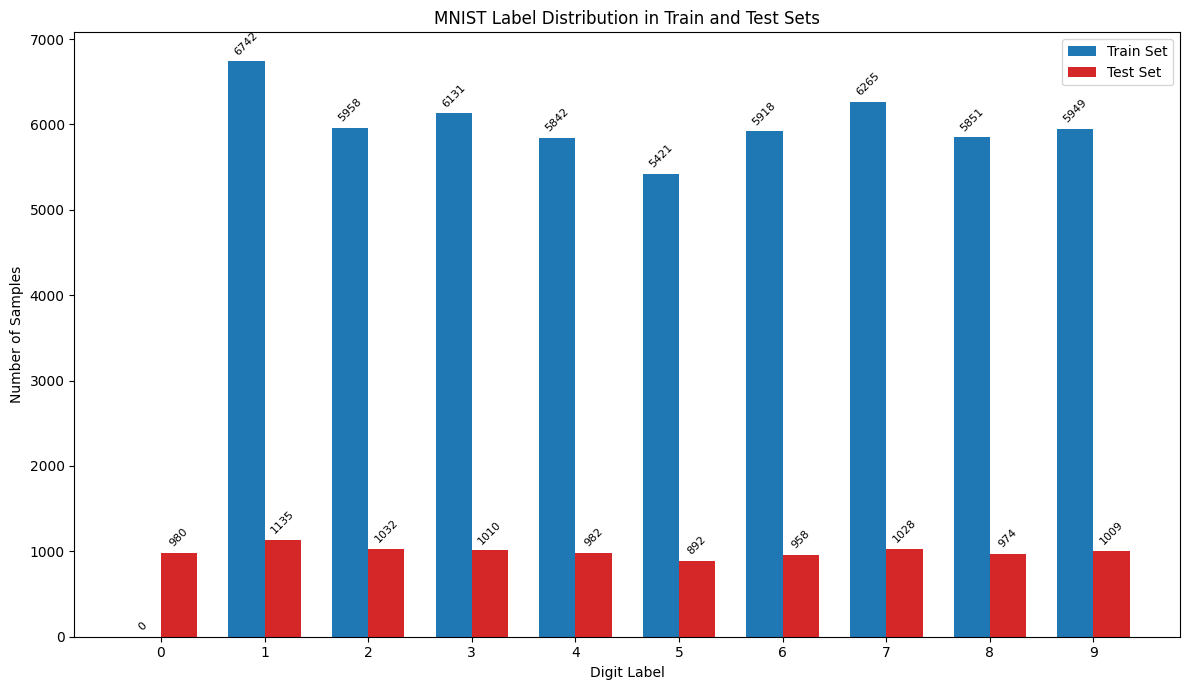

In [201]:
from torch.utils.data import Subset

transform = transforms.ToTensor()

# --- Load the (filtered) dataset ---
full_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
labels_to_remove = [0]  # example
indices = [i for i, (_, label) in enumerate(full_dataset) if label not in labels_to_remove]
train_ds = Subset(full_dataset, indices)
test_ds = datasets.MNIST(root="/content/data", train=False, download=True, transform=transform)

# --- Count the Label Distributions ---
train_label_distribution = Counter(train_ds.dataset.targets[train_ds.indices].numpy())
test_label_distribution = Counter(test_ds.targets.numpy())

labels = sorted(test_label_distribution.keys()) # Should be [0, 1, ..., 9]
train_counts = [train_label_distribution.get(label, 0) for label in labels] # Use .get() to handle the missing label 9
test_counts = [test_label_distribution[label] for label in labels]

x = np.arange(len(labels))  # The label locations on the x-axis
width = 0.35  # The width of the bars

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, train_counts, width, label='Train Set', color='tab:blue')
rects2 = ax.bar(x + width/2, test_counts, width, label='Test Set', color='tab:red')

ax.set_ylabel('Number of Samples')
ax.set_xlabel('Digit Label')
ax.set_title('MNIST Label Distribution in Train and Test Sets')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(rects1, padding=3, rotation=45, fontsize=8)
ax.bar_label(rects2, padding=3, rotation=45, fontsize=8)

fig.tight_layout()
plt.show()

In [202]:
BATCH_SIZE = 512

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=False)

In [203]:
DIM = 10_000  # We typically use 8k–20k; 10k is a solid default.
H, W = 28, 28
P = H * W

pos_hvs = make_position_hvs(P, DIM, device=DEVICE)
pos_hvs.shape, pos_hvs.device

(torch.Size([784, 10000]), device(type='cpu'))

In [220]:
t0 = time.time()
full_labels = list(range(10))
class_labels = list(set(full_labels)-set(labels_to_remove))
prototypes = build_class_prototypes(train_loader, pos_hvs, class_labels, threshold=0.5)
print("Prototypes:", prototypes.shape, "built in %.2fs" % (time.time() - t0))

Prototypes: torch.Size([9, 10000]) built in 9.15s


In [225]:
acc = evaluate_loader(test_loader, pos_hvs, prototypes, class_labels, threshold=0.5)
print(f"Test accuracy (MNIST): {acc:.2f}%")

Test accuracy (MNIST): 73.10%


# ConformalHDC

In [409]:
# --- Load the (filtered) dataset ---
generator = torch.Generator().manual_seed(0)

full_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
labels_to_remove = [1,4,7,9]  # example
indices = [i for i, (_, label) in enumerate(full_dataset) if label not in labels_to_remove]
filtered_ds = Subset(full_dataset, indices)

train_size = int(0.8 * len(filtered_ds))
calib_size = len(filtered_ds) - train_size
train_ds, calib_ds = random_split(filtered_ds, [train_size, calib_size])
test_ds = datasets.MNIST(root="/content/data", train=False, download=True, transform=transform)

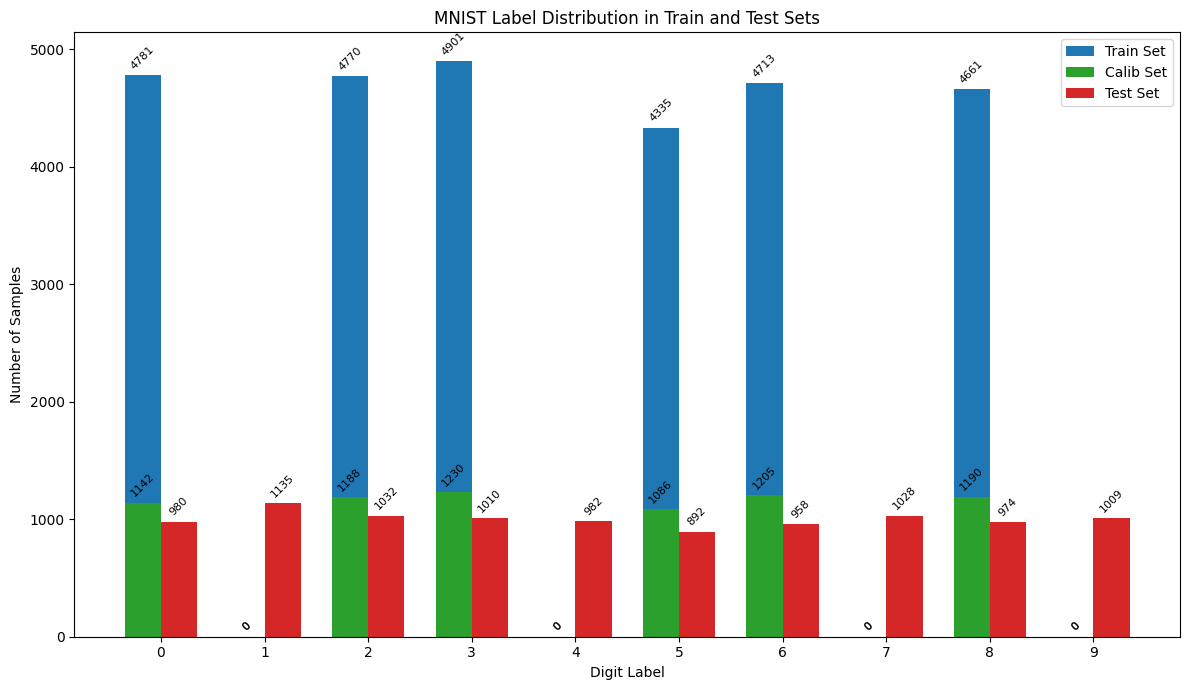

In [410]:
# --- Count the Label Distributions ---
train_label_distribution = Counter(train_ds.dataset.dataset.targets[[filtered_ds.indices[i] for i in train_ds.indices]].numpy())
calib_label_distribution = Counter(train_ds.dataset.dataset.targets[[filtered_ds.indices[i] for i in calib_ds.indices]].numpy())
test_label_distribution = Counter(test_ds.targets.numpy())

labels = sorted(test_label_distribution.keys()) # Should be [0, 1, ..., 9]
train_counts = [train_label_distribution.get(label, 0) for label in labels] # Use .get() to handle the missing label 9
calib_counts = [calib_label_distribution.get(label, 0) for label in labels] # Use .get() to handle the missing label 9
test_counts = [test_label_distribution[label] for label in labels]

x = np.arange(len(labels))  # The label locations on the x-axis
width = 0.35  # The width of the bars

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, train_counts, width, label='Train Set', color='tab:blue')
rects2 = ax.bar(x - width/2, calib_counts, width, label='Calib Set', color='tab:green')
rects3 = ax.bar(x + width/2, test_counts, width, label='Test Set', color='tab:red')

ax.set_ylabel('Number of Samples')
ax.set_xlabel('Digit Label')
ax.set_title('MNIST Label Distribution in Train and Test Sets')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(rects1, padding=3, rotation=45, fontsize=8)
ax.bar_label(rects2, padding=3, rotation=45, fontsize=8)
ax.bar_label(rects3, padding=3, rotation=45, fontsize=8)

fig.tight_layout()
plt.show()

In [411]:
BATCH_SIZE = 512

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=False)
calib_loader  = DataLoader(calib_ds,  batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=False)

In [412]:
DIM = 10_000  # We typically use 8k–20k; 10k is a solid default.
H, W = 28, 28
P = H * W

pos_hvs = make_position_hvs(P, DIM, device=DEVICE)
pos_hvs.shape, pos_hvs.device

(torch.Size([784, 10000]), device(type='cpu'))

In [413]:
t0 = time.time()
full_labels = list(range(10))
class_labels = list(set(full_labels)-set(labels_to_remove))
prototypes = build_class_prototypes(train_loader, pos_hvs, class_labels, threshold=0.5)
print("Prototypes:", prototypes.shape, "built in %.2fs" % (time.time() - t0))

Prototypes: torch.Size([6, 10000]) built in 5.55s


In [414]:
acc = evaluate_loader(test_loader, pos_hvs, prototypes, class_labels, threshold=0.5)
print(f"Test accuracy (MNIST): {acc:.2f}%")

Test accuracy (MNIST): 48.38%


In [415]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append('../')
from conformalHDC.models import *
from conformalHDC.methods import *
from conformalHDC.utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [416]:
calib_HVs = []
calib_labels = []
for imgs, labels in calib_loader:
    imgs  = imgs.to(pos_hvs.device, non_blocking=True)
    HVs = encode_binary_images_to_hvs(imgs, pos_hvs, threshold=0.5)
    calib_HVs.append(to_numpy(HVs))
    calib_labels.append(to_numpy(labels))
    
calib_HVs = np.concatenate(calib_HVs)
calib_labels = np.concatenate(calib_labels)

In [417]:
test_HVs = []
test_labels = []
for imgs, labels in test_loader:
    imgs  = imgs.to(pos_hvs.device, non_blocking=True)
    HVs = encode_binary_images_to_hvs(imgs, pos_hvs, threshold=0.5)
    test_HVs.append(to_numpy(HVs))
    test_labels.append(to_numpy(labels))
    
test_HVs = np.concatenate(test_HVs)
test_labels = np.concatenate(test_labels)

In [418]:
mask = np.isin(test_labels, labels_to_remove)
out_sample_indices = np.where(mask)[0]
in_sample_indices  = np.where(~mask)[0]

In [419]:
out_test_HVs = test_HVs[out_sample_indices]
out_test_labels = test_labels[out_sample_indices]

In [420]:
in_test_HVs = test_HVs[in_sample_indices]
in_test_labels = test_labels[in_sample_indices]

In [421]:
len(out_sample_indices)

4154

In [452]:
chdc = ConformalHDC(to_numpy(prototypes), class_labels)
alpha = 0.1

In [428]:
chdc.compute_calib_scores(calib_HVs, calib_labels)
m_psets = chdc.set_valued_CP(in_test_HVs, alpha, marginal=True)
eval_m_psets(m_psets, in_test_labels)

,M-coverage,M-size,M-size|cov
0,0.91105,2.464933,2.634623


In [429]:
lc_psets = chdc.set_valued_CP(in_test_HVs, alpha, marginal=False)
eval_lc_psets(lc_psets, in_test_labels)
eval_m_psets(lc_psets, in_test_labels)

,M-coverage,M-size,M-size|cov
0,0.911563,2.469723,2.613436


In [430]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="sim")
psets = chdc.set_valued_CP(in_test_HVs, alpha, marginal=True)
eval_m_psets(psets, in_test_labels)

,M-coverage,M-size,M-size|cov
0,0.91259,3.70065,4.018369


In [431]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="ratio")
psets = chdc.set_valued_CP(in_test_HVs, alpha, marginal=True)
eval_m_psets(psets, in_test_labels)

,M-coverage,M-size,M-size|cov
0,0.901129,1.557988,1.605543


In [432]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="inverse_quantile")
psets = chdc.set_valued_CP(in_test_HVs, alpha, marginal=True)
eval_m_psets(psets, in_test_labels)

,M-coverage,M-size,M-size|cov
0,0.900958,1.706808,1.72641


In [426]:
psets = chdc.predict(in_test_HVs).reshape(-1,1)
eval_m_psets(psets, in_test_labels)

,M-coverage,M-size,M-size|cov
0,0.827574,1.0,1.0


In [444]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="discount")
psets = chdc.set_valued_CP(out_test_HVs, 0.15, marginal=True)
sizes=[len(pset) for pset in psets]
zero_prop=len(np.where(np.array(sizes)==0)[0])/len(sizes)
zero_prop

0.46364949446316805

In [445]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="ratio")
psets = chdc.set_valued_CP(out_test_HVs, 0.15, marginal=True)
sizes=[len(pset) for pset in psets]
zero_prop=len(np.where(np.array(sizes)==0)[0])/len(sizes)
zero_prop

0.1494944631680308

In [447]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="sim")
psets = chdc.set_valued_CP(out_test_HVs, 0.15, marginal=True)
sizes=[len(pset) for pset in psets]
zero_prop=len(np.where(np.array(sizes)==0)[0])/len(sizes)
zero_prop

0.5137217140105922

In [448]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="penalized")
psets = chdc.set_valued_CP(out_test_HVs, 0.15, marginal=True)
sizes=[len(pset) for pset in psets]
zero_prop=len(np.where(np.array(sizes)==0)[0])/len(sizes)
zero_prop

0.023350987000481462

In [451]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="inverse_quantile")
psets = chdc.set_valued_CP(out_test_HVs, 0.5, marginal=True)
sizes=[len(pset) for pset in psets]
zero_prop=len(np.where(np.array(sizes)==0)[0])/len(sizes)
zero_prop

0.362782859894078

In [311]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="ratio")

In [312]:
test_scores_per_label = []
n_out = len(out_test_HVs)
for c_idx in chdc.canonical_indices:
    test_scores = chdc._compute_nonconformity_scores(out_test_HVs, [c_idx]*n_out, score_type=chdc.score_type) 
    test_scores_per_label.append(test_scores)

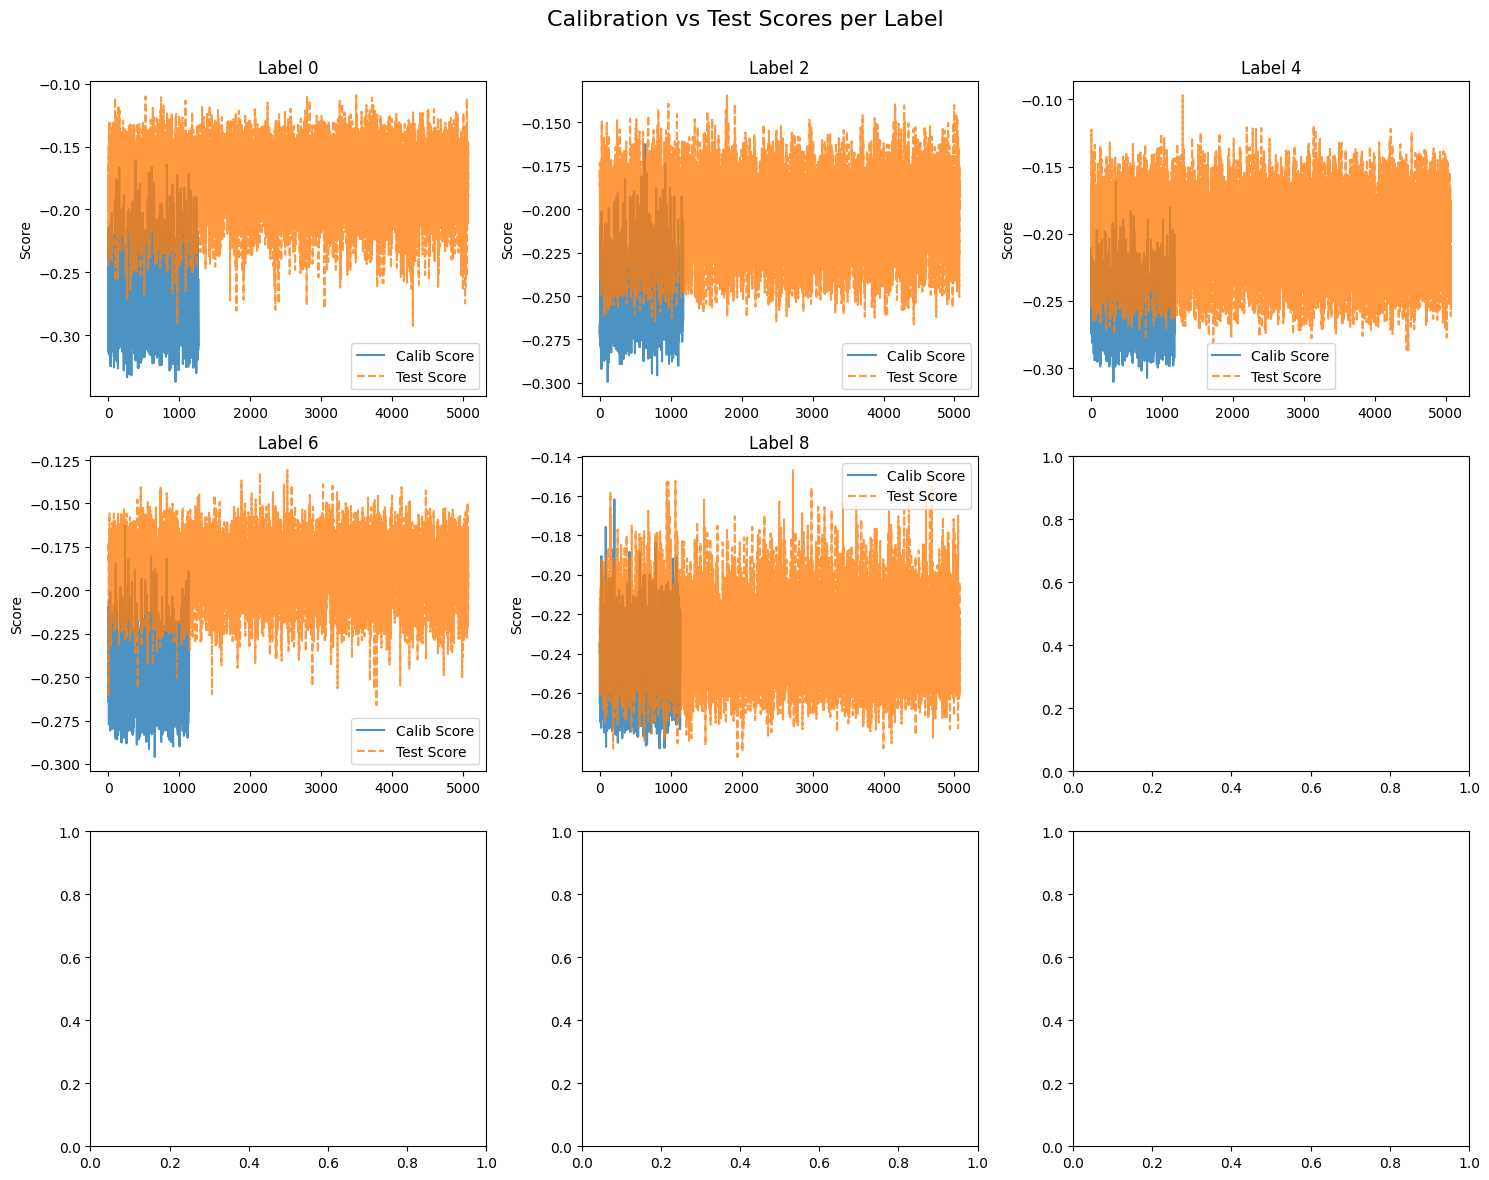

In [313]:
fig, axs = plt.subplots(3, 3, figsize=(15, 12))
axs_flat = axs.flatten()

for c_idx in chdc.canonical_indices:
    ax = axs_flat[c_idx]
    
    # 1. Get the data
    calib_data = chdc.calib_scores_per_label[c_idx]
    test_data = test_scores_per_label[ c_idx]
    
    # 2. Plot Calibration Scores (Blue)
    ax.plot(calib_data, label='Calib Score', color='tab:blue', alpha=0.8)
    
    # 3. Plot Test Scores (Orange)
    ax.plot(test_data, label='Test Score', color='tab:orange', alpha=0.8, linestyle='--')
    
    # 4. Styling
    ax.set_title(f"Label {chdc.class_labels[c_idx]}")
    ax.set_ylabel("Score")
    
    # Add legend to distinguish the lines
    ax.legend()

# Add a global title (optional)
fig.suptitle("Calibration vs Test Scores per Label", fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Adjust top to make room for suptitle
plt.show()

In [443]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="ratio")
preds = chdc.point_valued_CP(in_test_HVs, method='accurate')
acc = eval_accuracy(preds, in_test_labels)
acc

np.float64(0.8092712966130687)

In [439]:
preds = chdc.predict(in_test_HVs)
acc = eval_accuracy(preds, in_test_labels)
acc

np.float64(0.8275744098528909)

In [453]:
from sklearn.metrics import roc_auc_score, roc_curve

In [454]:
def evaluate_ood_detection(in_scores, out_scores):
    ''' Computes AUROC and FPR@95%TPR for OOD detection.
    
    Args:
        in_scores: Array of scores for In-Distribution data (should be HIGH).
        out_scores: Array of scores for Out-of-Distribution data (should be LOW).
        
    Returns:
        dict containing 'AUROC' and 'FPR95'
    '''
    # 1. Create Ground Truth Labels
    # Convention: 1 = In-Distribution, 0 = Out-of-Distribution
    y_true = np.concatenate([np.ones(len(in_scores)), np.zeros(len(out_scores))])
    
    # 2. Concatenate Scores
    y_scores = np.concatenate([in_scores, out_scores])
    
    # 3. Compute AUROC
    # This checks if a random ID sample has a higher score than a random OOD sample
    auroc = roc_auc_score(y_true, y_scores)
    
    # 4. Compute FPR at 95% TPR
    # To compute this, we treat OOD as the "Positive" class (1) and invert scores
    # so that Higher Score = More likely to be OOD (Low p-value)
    y_true_ood = 1 - y_true  # 1 = OOD, 0 = ID
    y_scores_ood = 1 - y_scores # Higher = OOD
    
    fpr, tpr, thresholds = roc_curve(y_true_ood, y_scores_ood)
    
    # Find the FPR value where TPR is closest to 0.95
    target_tpr = 0.95
    idx = np.argmin(np.abs(tpr - target_tpr))
    fpr95 = fpr[idx]
    
    return {
        "AUROC": auroc,
        "FPR95": fpr95
    }

In [466]:
chdc = ConformalHDC(to_numpy(prototypes), class_labels)

In [467]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="discount")
in_scores = chdc.get_max_p_value(in_test_HVs, marginal=True)
out_scores = chdc.get_max_p_value(out_test_HVs, marginal=True)
metrics = evaluate_ood_detection(in_scores, out_scores)
print(metrics)

{'AUROC': np.float64(0.8611149087203889), 'FPR95': np.float64(0.425419089976052)}


In [468]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="ratio")
in_scores = chdc.get_max_p_value(in_test_HVs, marginal=True)
out_scores = chdc.get_max_p_value(out_test_HVs, marginal=True)
metrics = evaluate_ood_detection(in_scores, out_scores)
print(metrics)

{'AUROC': np.float64(0.741968818187104), 'FPR95': np.float64(0.6223058501539515)}


In [469]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="inverse_quantile")
in_scores = chdc.get_max_p_value(in_test_HVs, marginal=True)
out_scores = chdc.get_max_p_value(out_test_HVs, marginal=True)
metrics = evaluate_ood_detection(in_scores, out_scores)
print(metrics)

{'AUROC': np.float64(0.4806141288744605), 'FPR95': np.float64(0.9505644885391721)}


In [470]:
chdc.compute_calib_scores(calib_HVs, calib_labels, score_type="sim")
in_scores = chdc.get_max_p_value(in_test_HVs, marginal=True)
out_scores = chdc.get_max_p_value(out_test_HVs, marginal=True)
metrics = evaluate_ood_detection(in_scores, out_scores)
print(metrics)

{'AUROC': np.float64(0.841770442974559), 'FPR95': np.float64(0.481354772494013)}
